✅ DATA ASLI BERHASIL DIMUAT!
File   : 53_FAR_EPOCX_730346_2026.03.03T13.54.59+07.00.md.mc.pm.fe.bp.csv
Subjek : FAR (female)
Kalimat: 'saya punya nomornya di sini'
Durasi : 708 timestep (2.77 detik)


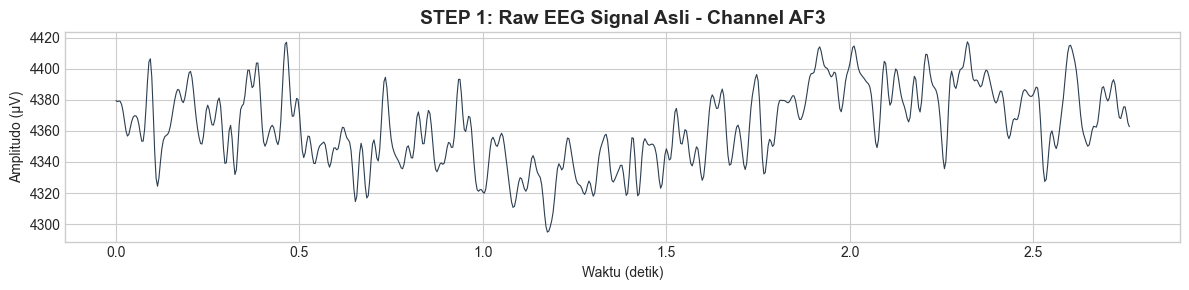

Memproses dekomposisi penuh (Mohon tunggu)...
Selesai! Sinyal dipecah menjadi 5 IMF dan 1 Residu Akhir.


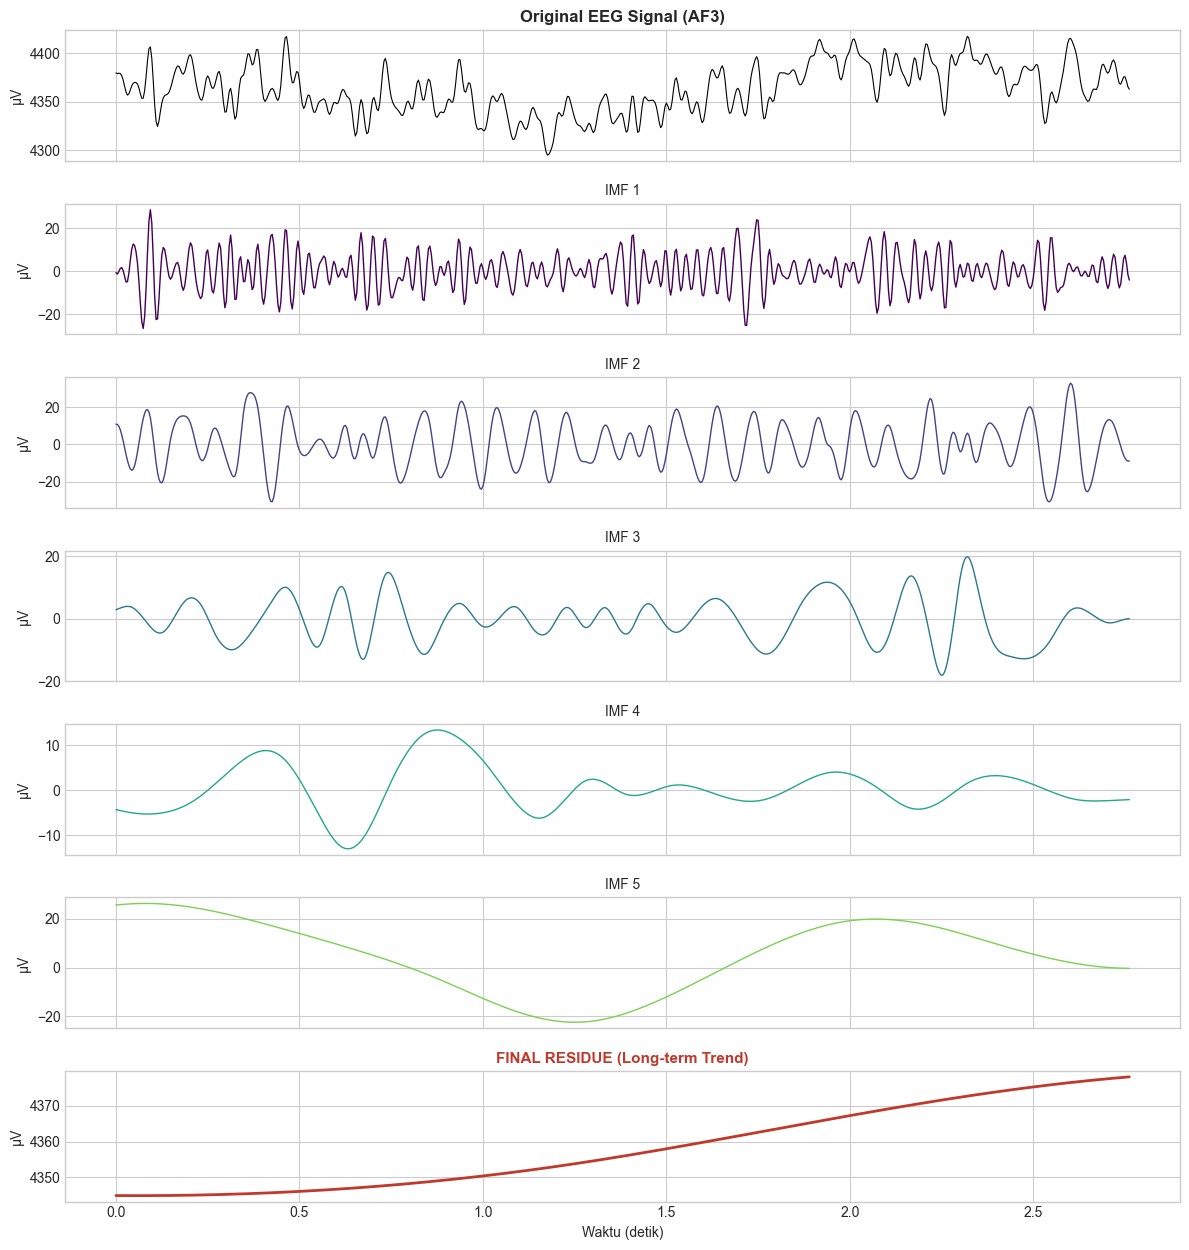

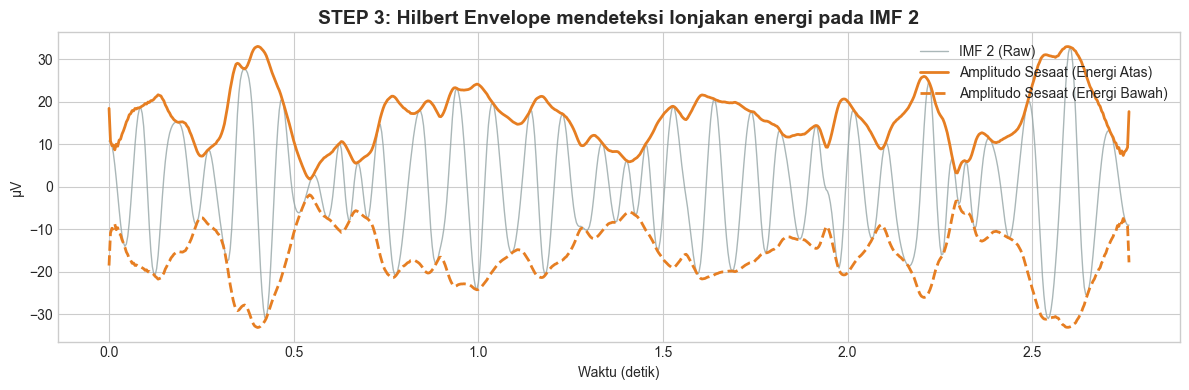

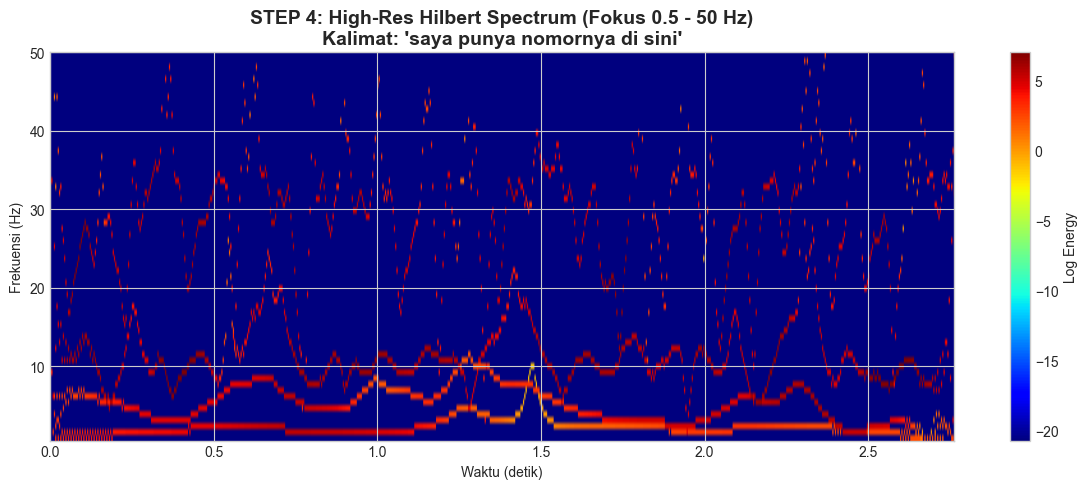

Ukuran Awal Spektrum: 65 bins x 708 timestep
Ukuran Akhir Input  : 65 bins x 22 frames


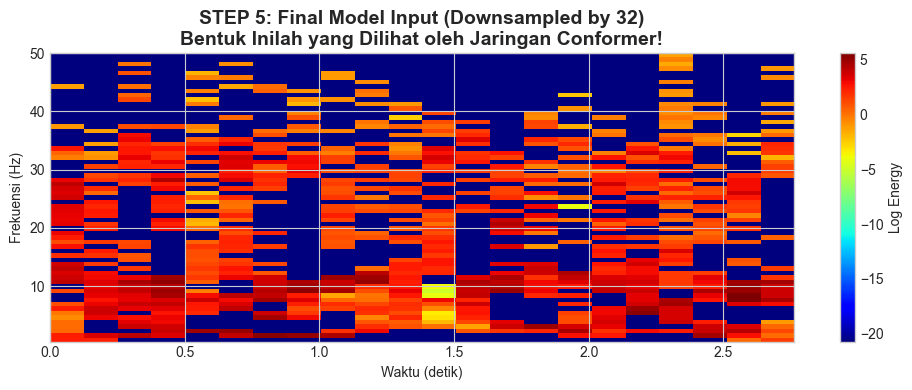

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import CEEMDAN
from scipy.signal import hilbert
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ====================================================================
# STEP 1: LOAD DATA ASLI
# ====================================================================
# Sesuaikan PROJECT_ROOT jika posisi file .ipynb Anda berbeda.
# Asumsi saat ini: .ipynb berada di dalam folder src/notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../../../')) 
DATASET_CSV = os.path.join(PROJECT_ROOT, 'dataset/cleaned_transcript_mapping.csv')
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'dataset/raw')

# 1. Buka mapping CSV & Ambil 1 sampel random
df_map = pd.read_csv(DATASET_CSV)
sample_row = df_map.sample(1, random_state=42).iloc[0] # Ganti random_state untuk sampel lain

id_val = sample_row['id']
subject = sample_row['subject']
gender = sample_row['gender']
sentence = sample_row['sentence']

# 2. Cari file CSV aslinya di folder raw
csv_folder = os.path.join(RAW_DATA_PATH, gender, subject, 'csv')
matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]

if not matching_files:
    raise FileNotFoundError(f"File untuk ID {id_val} tidak ditemukan di {csv_folder}")

file_path = os.path.join(csv_folder, matching_files[0])

# 3. Ekstrak data Channel AF3 (Frontal Kiri)
df_eeg = pd.read_csv(file_path, skiprows=1)
eeg_channels = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

# Ambil channel pertama (AF3)
eeg_channel = df_eeg[eeg_channels].values[:, 0] 

# Konfigurasi Waktu
fs = 256
n_samples = len(eeg_channel)
t = np.arange(n_samples) / fs

print(f"✅ DATA ASLI BERHASIL DIMUAT!")
print(f"File   : {matching_files[0]}")
print(f"Subjek : {subject} ({gender})")
print(f"Kalimat: '{sentence}'")
print(f"Durasi : {n_samples} timestep ({(n_samples/fs):.2f} detik)")

# VISUALISASI STEP 1: SINYAL ASLI
plt.figure(figsize=(12, 3))
plt.plot(t, eeg_channel, color='#2c3e50', linewidth=0.8)
plt.title(f"STEP 1: Raw EEG Signal Asli - Channel AF3", fontsize=14, fontweight='bold')
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo (µV)")
plt.tight_layout()
plt.show()

# ====================================================================
# STEP 2: CEEMDAN DECOMPOSITION (FULL TO RESIDUE)
# ====================================================================
# Kita tidak membatasi max_imf agar algoritma berhenti secara alami
ceemdan = CEEMDAN(trials=15, noise_scale=0.2, parallel=True) 

print("Memproses dekomposisi penuh (Mohon tunggu)...")
# Biarkan max_imf default untuk mendapatkan seluruh komponen hingga residu
components = ceemdan(eeg_channel) 

# Dalam output PyEMD:
# Komponen index 0 sampai n-2 adalah IMF
# Komponen terakhir (index n-1) adalah RESIDU
imfs = components[:-1]
residue = components[-1]

n_imfs = len(imfs)
print(f"Selesai! Sinyal dipecah menjadi {n_imfs} IMF dan 1 Residu Akhir.")

# VISUALISASI STEP 2: FULL DECOMPOSITION
# Kita buat grid: Original + semua IMF + Residu
total_plots = n_imfs + 2
fig, axes = plt.subplots(total_plots, 1, figsize=(12, 1.8 * total_plots), sharex=True)

# 1. Plot Sinyal Asli
axes[0].plot(t, eeg_channel, 'k', linewidth=0.8)
axes[0].set_title("Original EEG Signal (AF3)", fontweight='bold')
axes[0].set_ylabel("µV")

# 2. Plot Semua IMF
for i in range(n_imfs):
    axes[i+1].plot(t, imfs[i], color=plt.cm.viridis(i / n_imfs), linewidth=1)
    axes[i+1].set_title(f"IMF {i+1}", fontsize=10)
    axes[i+1].set_ylabel("µV")

# 3. Plot Residu Akhir
axes[-1].plot(t, residue, color='#c0392b', linewidth=2)
axes[-1].set_title("FINAL RESIDUE (Long-term Trend)", fontsize=11, fontweight='bold', color='#c0392b')
axes[-1].set_ylabel("µV")

plt.xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

# ====================================================================
# STEP 3: HILBERT TRANSFORM
# ====================================================================
amplitudes = np.zeros_like(imfs)
frequencies = np.zeros_like(imfs)

for i in range(num_imfs):
    analytic_signal = hilbert(imfs[i])
    
    # 1. Instantaneous Amplitude (Amplop/Energi)
    amplitudes[i] = np.abs(analytic_signal)
    
    # 2. Instantaneous Frequency (Kecepatan Gelombang Sesaat)
    phase = np.unwrap(np.angle(analytic_signal))
    freq = (np.diff(phase) / (2.0 * np.pi) * fs)
    frequencies[i] = np.insert(freq, 0, freq[0]) 

# VISUALISASI STEP 3: CONTOH PADA IMF KE-2
plt.figure(figsize=(12, 4))
imf_idx = 1 # Indeks 1 = IMF ke-2

plt.plot(t, imfs[imf_idx], label=f'IMF {imf_idx+1} (Raw)', color='#95a5a6', alpha=0.8, linewidth=1)
plt.plot(t, amplitudes[imf_idx], label='Amplitudo Sesaat (Energi Atas)', color='#e67e22', linewidth=2)
plt.plot(t, -amplitudes[imf_idx], label='Amplitudo Sesaat (Energi Bawah)', color='#e67e22', linewidth=2, linestyle='--')

plt.title(f"STEP 3: Hilbert Envelope mendeteksi lonjakan energi pada IMF {imf_idx+1}", fontsize=14, fontweight='bold')
plt.xlabel("Waktu (detik)")
plt.ylabel("µV")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ====================================================================
# STEP 4: BINNING KE DALAM 65 PITA FREKUENSI
# ====================================================================
f_min, f_max = 0.5, 50.0
n_bins = 65
freq_edges = np.linspace(f_min, f_max, n_bins + 1)

# Kanvas spektrum (65 bins x Panjang Waktu)
hilbert_spec = np.zeros((n_bins, n_samples))

for i in range(num_imfs):
    amp = amplitudes[i]
    freq = frequencies[i]
    
    bin_indices = np.digitize(freq, freq_edges) - 1
    
    for t_idx in range(n_samples):
        b = bin_indices[t_idx]
        if 0 <= b < n_bins:
            hilbert_spec[b, t_idx] += (amp[t_idx] ** 2)

# Mengubah orientasi sumbu Y agar 0 Hz di bawah, 50 Hz di atas
y_labels = np.linspace(f_min, f_max, 6) # Untuk label sumbu Y

# VISUALISASI STEP 4
plt.figure(figsize=(12, 5))
im = plt.imshow(np.log(hilbert_spec + 1e-9), aspect='auto', origin='lower', 
                cmap='jet', extent=[0, t[-1], f_min, f_max])

plt.colorbar(im, label='Log Energy')
plt.title(f"STEP 4: High-Res Hilbert Spectrum (Fokus 0.5 - 50 Hz)\nKalimat: '{sentence}'", fontsize=14, fontweight='bold')
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.tight_layout()
plt.show()

# ====================================================================
# STEP 5: DOWNSAMPLING (HOP_LENGTH = 32)
# ====================================================================
# Sinyal awal sepanjang ~768 timestep terlalu besar. 
# Kita mampatkan dengan merata-ratakan tiap 32 timestep (~0.125 detik)
hop_length = 32
n_frames = n_samples // hop_length

framed_spec = np.zeros((n_bins, n_frames))

for t_idx in range(n_frames):
    start = t_idx * hop_length
    end = start + hop_length
    framed_spec[:, t_idx] = np.mean(hilbert_spec[:, start:end], axis=1)

final_features = np.log(framed_spec + 1e-9)

print(f"Ukuran Awal Spektrum: 65 bins x {n_samples} timestep")
print(f"Ukuran Akhir Input  : 65 bins x {n_frames} frames")

# VISUALISASI STEP 5
plt.figure(figsize=(10, 4))
im = plt.imshow(final_features, aspect='auto', origin='lower', 
                cmap='jet', extent=[0, t[-1], f_min, f_max])

plt.colorbar(im, label='Log Energy')
plt.title(f"STEP 5: Final Model Input (Downsampled by {hop_length})\nBentuk Inilah yang Dilihat oleh Jaringan Conformer!", fontsize=14, fontweight='bold')
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.tight_layout()
plt.show()

